In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from math import pi
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [32]:
# (1) Prep and load data

columns = ["Unit", "Cycle", "Set1", "Set2", "Set3"] + [f"S{i}" for i in range(1, 22)]
# Drop non-variant sensors to reduce noise
drop_sensors = ['S1', 'S5', 'S10', 'S16', 'S18', 'S19']
features = [f for f in columns[1:] if f not in drop_sensors] # Keeping 'Cycle' as a feature

# Load datasets
train_df = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=columns)
test_df = pd.read_csv('test_FD001.txt', sep=r'\s+', header=None, names=columns)
true_rul = pd.read_csv('RUL_FD001.txt', header=None, names=['RUL'])

In [33]:
# (2) Define target variable & apply rolling average

# Define our target: The total lifespan of the engine
train_df['max_cycles'] = train_df.groupby('Unit')['Cycle'].transform('max')

# Apply Rolling Average Smoothing (Window = 10)
# Filters out high-frequency sensor noise
sensor_cols = [f"S{i}" for i in range(1, 22)]
train_df[sensor_cols] = train_df.groupby('Unit')[sensor_cols].rolling(window=10, min_periods=1).mean().reset_index(level=0, drop=True)

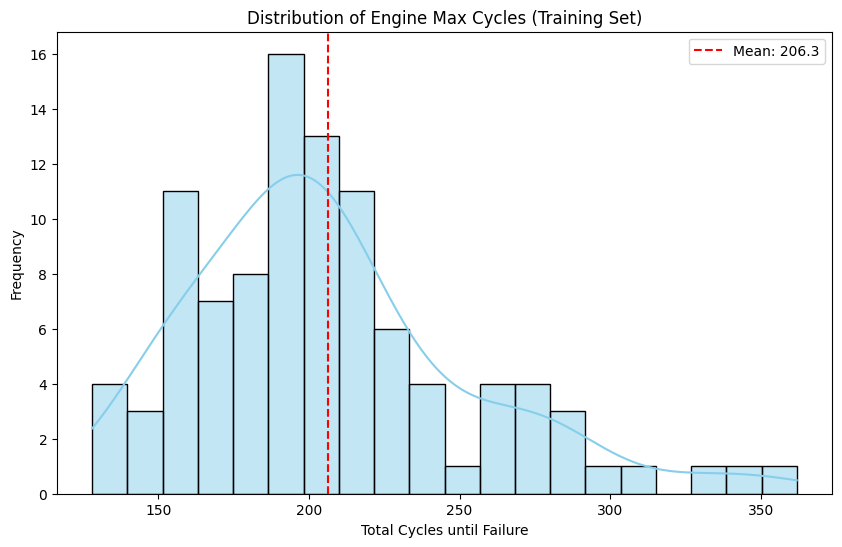

In [34]:
# Calculate the max_cycles for each engine unit in the training set
max_cycles = train_df.groupby('Unit')['Cycle'].max()

plt.figure(figsize=(10, 6))
sns.histplot(max_cycles, bins=20, kde=True, color='skyblue')
plt.axvline(max_cycles.mean(), color='red', linestyle='--', label=f'Mean: {max_cycles.mean():.1f}')
plt.title('Distribution of Engine Max Cycles (Training Set)')
plt.xlabel('Total Cycles until Failure')
plt.ylabel('Frequency')
plt.legend()
plt.show()

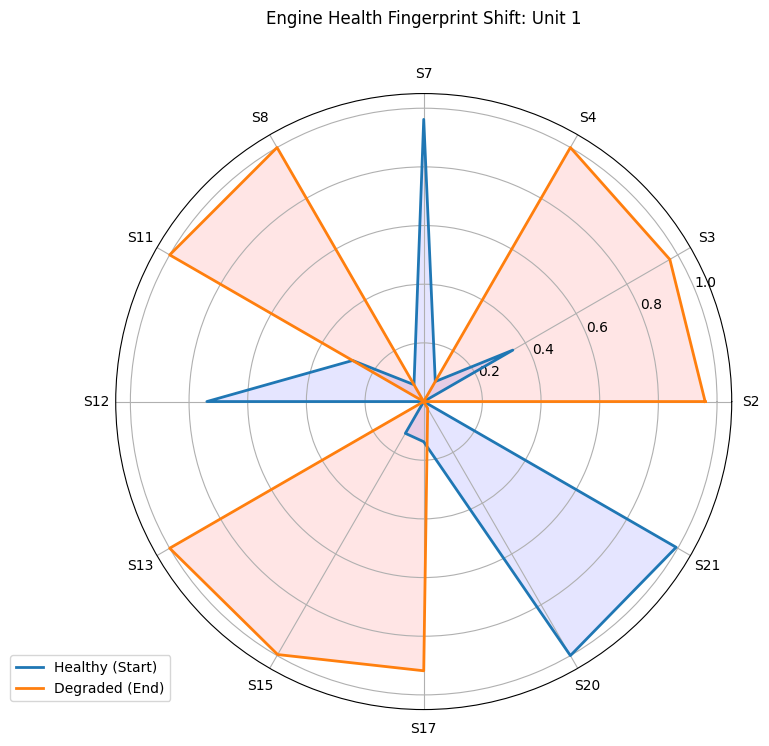

In [35]:
def plot_radar_chart(df, unit_id):
    # 1. Normalize data (0 to 1 scale) so all sensors can be compared
    sensors = [f'S{i}' for i in [2, 3, 4, 7, 8, 11, 12, 13, 15, 17, 20, 21]] # Key sensors
    df_unit = df[df['Unit'] == unit_id].copy()
    for s in sensors:
        df_unit[s] = (df_unit[s] - df_unit[s].min()) / (df_unit[s].max() - df_unit[s].min())

    # 2. Extract 'Start of Life' and 'End of Life' snapshots
    start = df_unit.iloc[0][sensors].values.flatten().tolist()
    end = df_unit.iloc[-1][sensors].values.flatten().tolist()
    start += start[:1] # Close the circle
    end += end[:1]

    # 3. Setup Angles
    angles = [n / float(len(sensors)) * 2 * pi for n in range(len(sensors))]
    angles += angles[:1]

    # 4. Plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    plt.xticks(angles[:-1], sensors)

    ax.plot(angles, start, linewidth=2, linestyle='solid', label="Healthy (Start)")
    ax.fill(angles, start, 'b', alpha=0.1)

    ax.plot(angles, end, linewidth=2, linestyle='solid', label="Degraded (End)")
    ax.fill(angles, end, 'r', alpha=0.1)

    plt.title(f'Engine Health Fingerprint Shift: Unit {unit_id}', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.show()

plot_radar_chart(train_df, unit_id=1)

In [44]:
# Prepare data for plotting both raw and smoothed trends

# Reload the original training data for raw plot
columns = ["Unit", "Cycle", "Set1", "Set2", "Set3"] + [f"S{i}" for i in range(1, 22)]
train_df_raw_for_plot = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=columns)

# Create a copy for smoothing to avoid modifying the raw data
train_df_smoothed_for_plot = train_df_raw_for_plot.copy()

# Apply rolling average smoothing (window = 10) to the copy
sensor_cols = [f"S{i}" for i in range(1, 22)]
train_df_smoothed_for_plot[sensor_cols] = train_df_smoothed_for_plot.groupby('Unit')[sensor_cols].rolling(window=10, min_periods=1).mean().reset_index(level=0, drop=True)

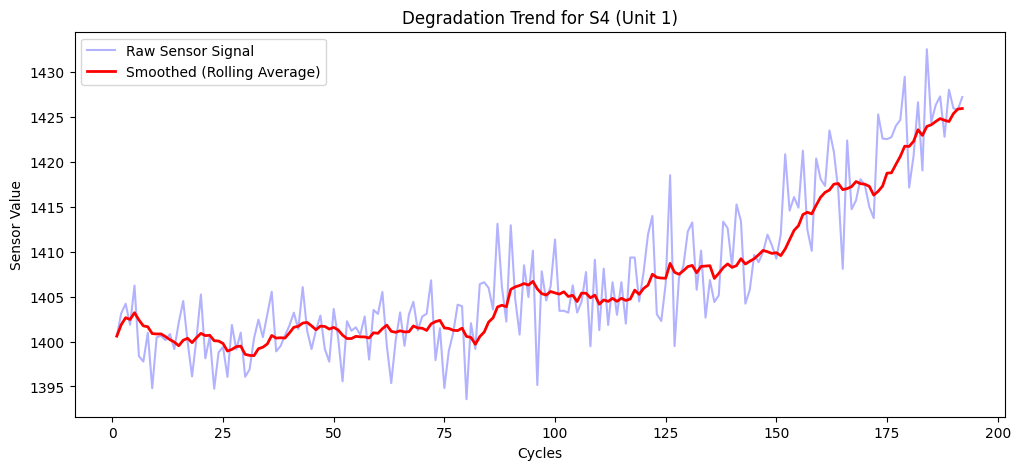

In [45]:
unit_id = 1
sensor_name = 'S4' # Exhaust Gas Temp

plt.figure(figsize=(12, 5))

# Plot raw data in BLUE with transparency (alpha)
# This creates a "cloud" of noise in the background
plt.plot(
    train_df_raw_for_plot[train_df_raw_for_plot['Unit']==unit_id]['Cycle'],
    train_df_raw_for_plot[train_df_raw_for_plot['Unit']==unit_id][sensor_name],
    color='blue',
    alpha=0.3,
    label='Raw Sensor Signal'
)

# Plot smoothed data in RED
# This draws the clear trend line on top of the noise
plt.plot(
    train_df_smoothed_for_plot[train_df_smoothed_for_plot['Unit']==unit_id]['Cycle'],
    train_df_smoothed_for_plot[train_df_smoothed_for_plot['Unit']==unit_id][sensor_name],
    color='red',
    linewidth=2,
    label='Smoothed (Rolling Average)'
)

plt.title(f'Degradation Trend for {sensor_name} (Unit {unit_id})')
plt.xlabel('Cycles')
plt.ylabel('Sensor Value')
plt.legend()
plt.show()

In [56]:
# Establish naive baseline based on Training data
target_per_unit = train_df.groupby('Unit')['Cycle'].max()
baseline_val = target_per_unit.mean()

# Create a prediction array for the TEST set
# (Assuming y_test is your ground truth for the test engines)
baseline_prediction_test = np.full(shape=y_test.shape, fill_value=baseline_val)

# Calculate ALL Baseline Metrics
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_prediction_test))
baseline_mae = mean_absolute_error(y_test, baseline_prediction_test)
baseline_r2 = r2_score(y_test, baseline_prediction_test)

print(f"--- NAIVE BASELINE PERFORMANCE (Test Set) ---")
print(f"Baseline Mean Max Cycles: {baseline_val:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline R-Squared: {baseline_r2:.2f}")

--- NAIVE BASELINE PERFORMANCE (Test Set) ---
Baseline Mean Max Cycles: 206.31
Baseline RMSE: 43.82
Baseline MAE: 34.10
Baseline R-Squared: -0.00


In [57]:
# (3) Train model (use regularization)

# Regularization parameters prevent the model from overfitting
model = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,           # Limit tree depth to encourage generalization
    min_samples_leaf=15,    # Ensure rules apply to multiple cycles
    max_features='sqrt',    # Introduce variety in tree decision paths
    random_state=42
)

X_train = train_df[features]
y_train = train_df['max_cycles']
model.fit(X_train, y_train)

# Generate predictions for the training data
y_train_pred = model.predict(X_train)

# Calculate training metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"--- TRAINING EVALUATION ---")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Train MAE: {mae_train:.2f}")
print(f"Train R-Squared: {r2_train:.2f}")

# Example Business Output
print(f"\nUnit 1 Prediction: Predicted Max={y_train_pred[0]:.0f} | Actual Max={y_train[0]:.0f}")

--- TRAINING EVALUATION ---
Train RMSE: 29.00
Train MAE: 21.49
Train R-Squared: 0.66

Unit 1 Prediction: Predicted Max=211 | Actual Max=192


In [58]:
# (4) Data preparation for testing (use smoothing)

# CRITICAL: We must smooth the test data BEFORE taking the last cycle snapshot
test_df[sensor_cols] = test_df.groupby('Unit')[sensor_cols].rolling(window=10, min_periods=1).mean().reset_index(level=0, drop=True)

# Extract the final snapshot for each unit
test_last_cycle = test_df.groupby('Unit').last().reset_index()

# Calculate the Ground Truth Max Cycles for evaluation
# Actual Max = Current Age + Actual Remaining Life
test_last_cycle['actual_max_cycles'] = test_last_cycle['Cycle'] + true_rul['RUL']

In [59]:
# (5) Final evaluation
X_test = test_last_cycle[features]
y_test = test_last_cycle['actual_max_cycles']

# Predictions
predicted_max = model.predict(X_test)
predicted_rul = predicted_max - test_last_cycle['Cycle']

# Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_test, predicted_max))
mae = mean_absolute_error(y_test, predicted_max)
r2 = r2_score(y_test, predicted_max)

print(f"--- TESTING EVALUATION ---")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test R-Squared: {r2:.2f}")

# Example Business Output
print(f"\nUnit 1 Prediction: Predicted Max={predicted_max[0]:.0f} | Actual Max={y_test[0]:.0f}")

--- TESTING EVALUATION ---
Test RMSE: 31.76
Test MAE: 25.07
Test R-Squared: 0.47

Unit 1 Prediction: Predicted Max=204 | Actual Max=143


Text(0.5, 1.0, 'Error Analysis: Do we over-predict or under-predict?')

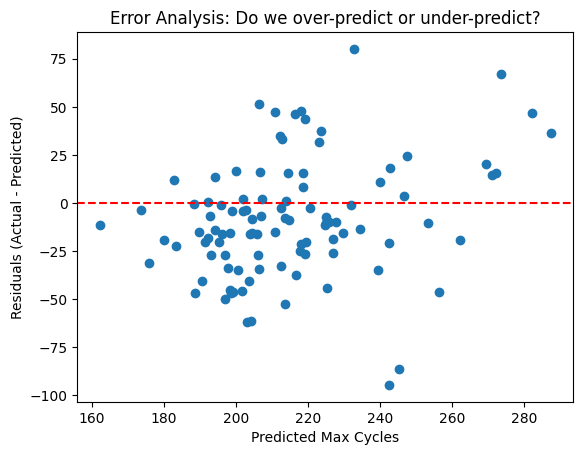

In [60]:
plt.scatter(predicted_max, (y_test - predicted_max))
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Max Cycles')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Error Analysis: Do we over-predict or under-predict?')

/tmp/ipykernel_699/1925603373.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


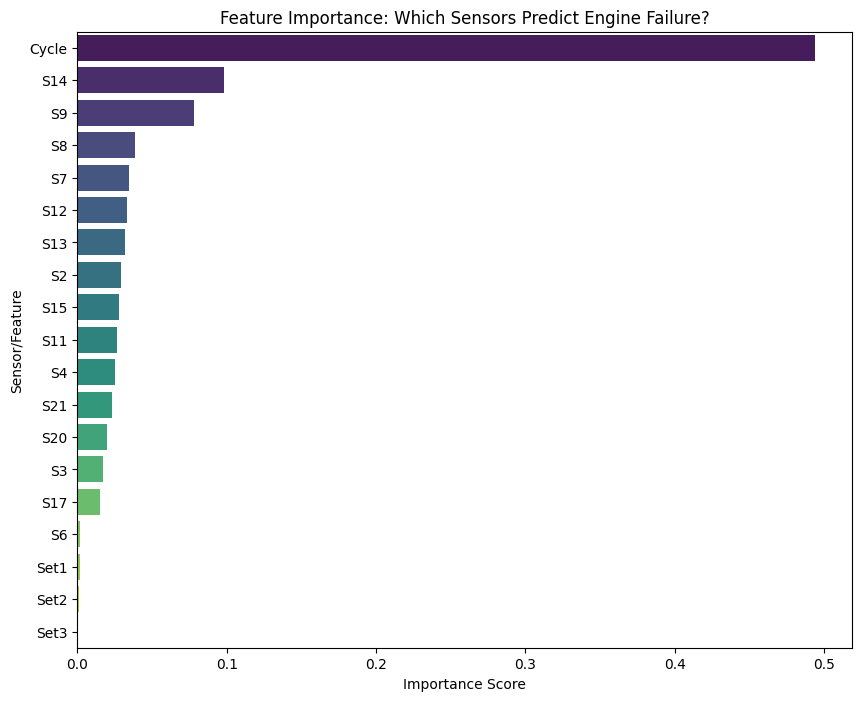

In [61]:
# Plot Feature Importance

# Extract importances from the trained model
importances = model.feature_importances_
feature_names = features # This ensures we use the filtered list of sensors

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance: Which Sensors Predict Engine Failure?')
plt.xlabel('Importance Score')
plt.ylabel('Sensor/Feature')
plt.show()